# NSL-KDD Intrusion Detection

**Objective:** Train and evaluate ML models (Logistic Regression, Random Forest) to detect network attacks using NSL-KDD dataset.

### Import Packages

In [1]:
import sys
sys.path.append("..")

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from src.train import train, evaluate_model
from src.preprocess import load_data, preprocess

### Train the models

In [2]:
df_train, df_test = load_data('../data/KDDTrain+.txt', '../data/KDDTest+.txt')
df = pd.concat([df_train, df_test], ignore_index=True)
X, y = preprocess(df)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [3]:
lr, rf = train(X_train, y_train) # Set save=True to save the models inside models/ directory

You can also load the saved models instead of training them (training takes ~20 seconds)

In [ ]:
import joblib

lr = joblib.load('../models/logistic_regression.joblib')
rf = joblib.load('../models/random_forest.joblib')

### Logistic Regression

Classification report for Logistic Regression:
              precision    recall  f1-score   support

           0       0.95      0.97      0.96     15392
           1       0.97      0.94      0.95     14312

    accuracy                           0.96     29704
   macro avg       0.96      0.96      0.96     29704
weighted avg       0.96      0.96      0.96     29704



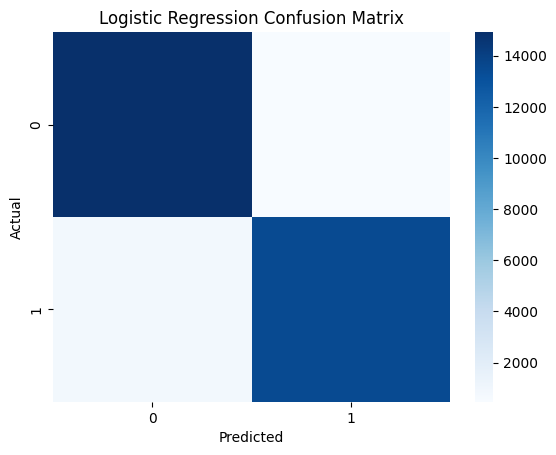

In [4]:
report, conf_mat = evaluate_model(lr, X_test, y_test)

print(f'Classification report for Logistic Regression:')
print(report)

sns.heatmap(conf_mat, cmap='Blues')
plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### Random Forest Classifier

Classification report for Random Forest Classifier:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00     15392
           1       1.00      0.99      0.99     14312

    accuracy                           1.00     29704
   macro avg       1.00      1.00      1.00     29704
weighted avg       1.00      1.00      1.00     29704



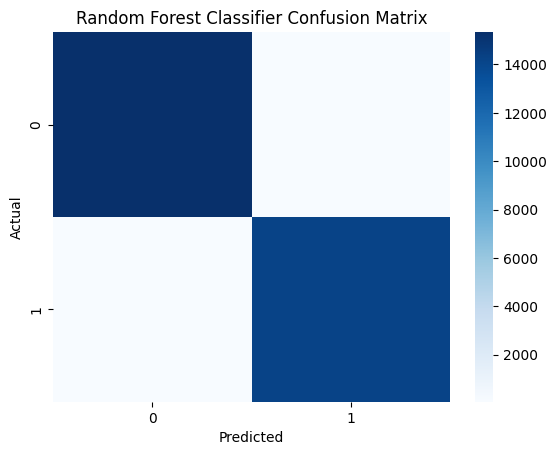

In [5]:
report, conf_mat = evaluate_model(rf, X_test, y_test)

print(f'Classification report for Random Forest Classifier:')
print(report)

sns.heatmap(conf_mat, cmap='Blues')
plt.title('Random Forest Classifier Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()